# 🚗 Vehicle Price Prediction — Supervised Learning Project

## 1. Import Libraries & Load Data

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('car_prices.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (558837, 16)


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [21]:
df.describe()

,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


## 2. Data Cleaning

In [22]:
# Missing values
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

transmission    65352
body            13195
condition       11820
trim            10651
model           10399
make            10301
color             749
interior          749
odometer           94
mmr                38
sellingprice       12
saledate           12
vin                 4
dtype: int64


In [23]:
# Extract features from saledate before dropping it
# Format: "Tue Dec 16 2014 12:30:00 GMT-0800 (PST)"
month_map = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
             'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}

df['sale_year'] = df['saledate'].astype(str).str.split().str[3]
df['sale_year'] = pd.to_numeric(df['sale_year'], errors='coerce')

df['sale_month'] = df['saledate'].astype(str).str.split().str[1].str.lower().map(month_map)

# Drop columns not useful for prediction
df.drop(columns=['vin', 'seller', 'saledate'], inplace=True)

# Drop duplicates
df.drop_duplicates(inplace=True)

# Fill missing values — median for numeric, mode for categorical
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Standardise text to lowercase
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.lower().str.strip()

# Remove outliers using IQR method
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(data)
    data = data[(data[column] >= lower) & (data[column] <= upper)]
    print(f"  {column}: removed {before - len(data):,} rows  (bounds: {lower:,.0f} to {upper:,.0f})")
    return data

print("Outlier removal (IQR method):")
df = remove_outliers_iqr(df, 'sellingprice')
df = remove_outliers_iqr(df, 'odometer')

print(f"Cleaned shape: {df.shape}")
print(f"Remaining nulls: {df.isnull().sum().sum()}")

Outlier removal (IQR method):
  sellingprice: removed 16,354 rows  (bounds: -10,050 to 35,150)
  odometer: removed 9,712 rows  (bounds: -77,530 to 207,602)
Cleaned shape: (532771, 15)
Remaining nulls: 0


## 3. Exploratory Data Analysis (EDA)

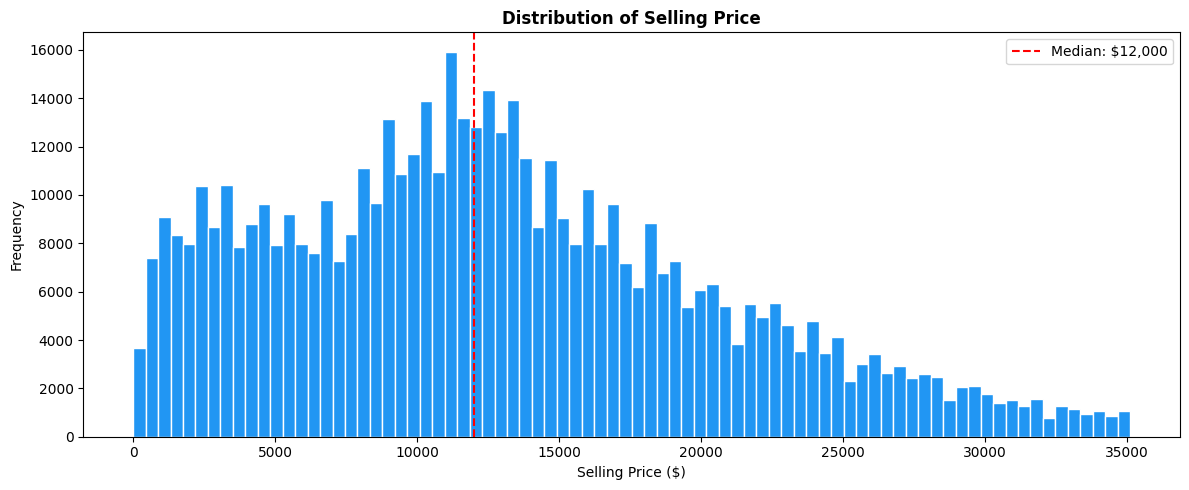

In [24]:
# Distribution of Selling Price
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df['sellingprice'], bins=80, color='#2196F3', edgecolor='white')
ax.axvline(df['sellingprice'].median(), color='red', linestyle='--', label=f"Median: ${df['sellingprice'].median():,.0f}")
ax.set_title('Distribution of Selling Price', fontweight='bold')
ax.set_xlabel('Selling Price ($)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

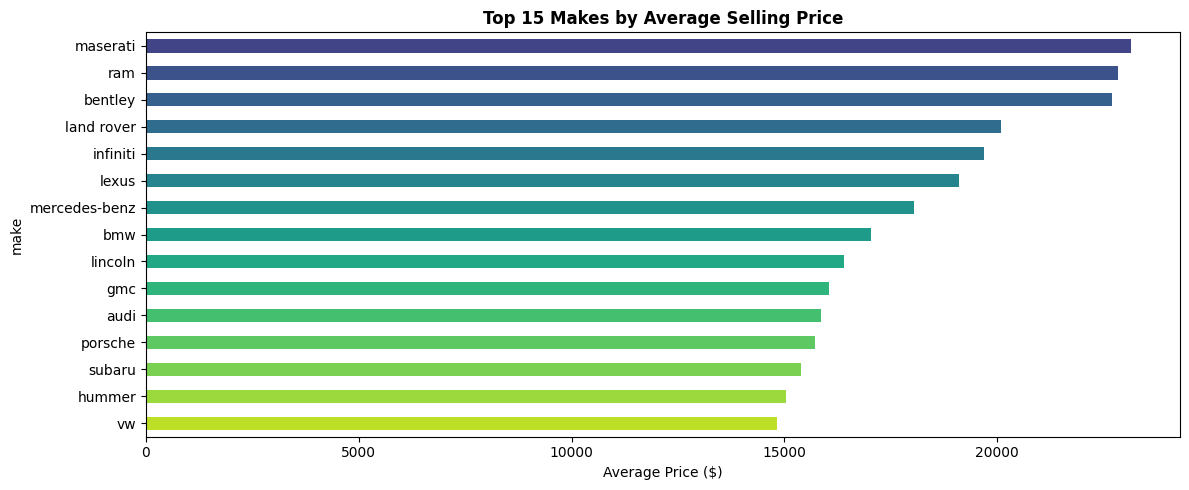

In [25]:
# Top 15 Makes by Average Price
avg_price = df.groupby('make')['sellingprice'].mean().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(12, 5))
avg_price.plot(kind='barh', color=plt.cm.viridis(np.linspace(0.2, 0.9, 15)), ax=ax)
ax.set_title('Top 15 Makes by Average Selling Price', fontweight='bold')
ax.set_xlabel('Average Price ($)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

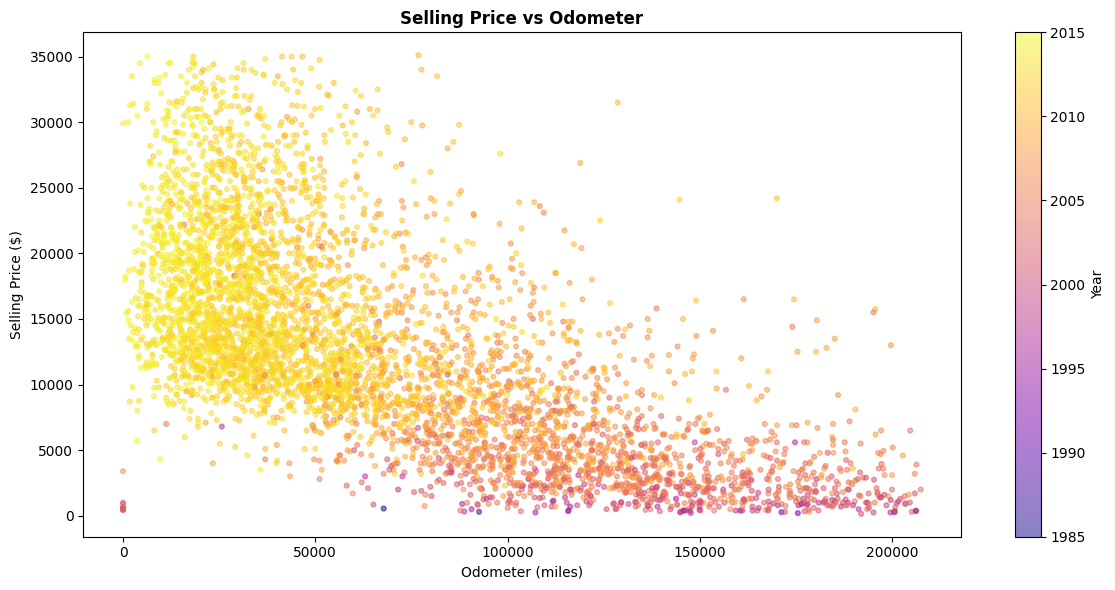

In [26]:
# Selling Price vs Odometer
sample = df.sample(5000, random_state=42)
fig, ax = plt.subplots(figsize=(12, 6))
sc = ax.scatter(sample['odometer'], sample['sellingprice'], c=sample['year'], cmap='plasma', alpha=0.5, s=12)
ax.set_title('Selling Price vs Odometer', fontweight='bold')
ax.set_xlabel('Odometer (miles)')
ax.set_ylabel('Selling Price ($)')
plt.colorbar(sc, label='Year')
plt.tight_layout()
plt.show()

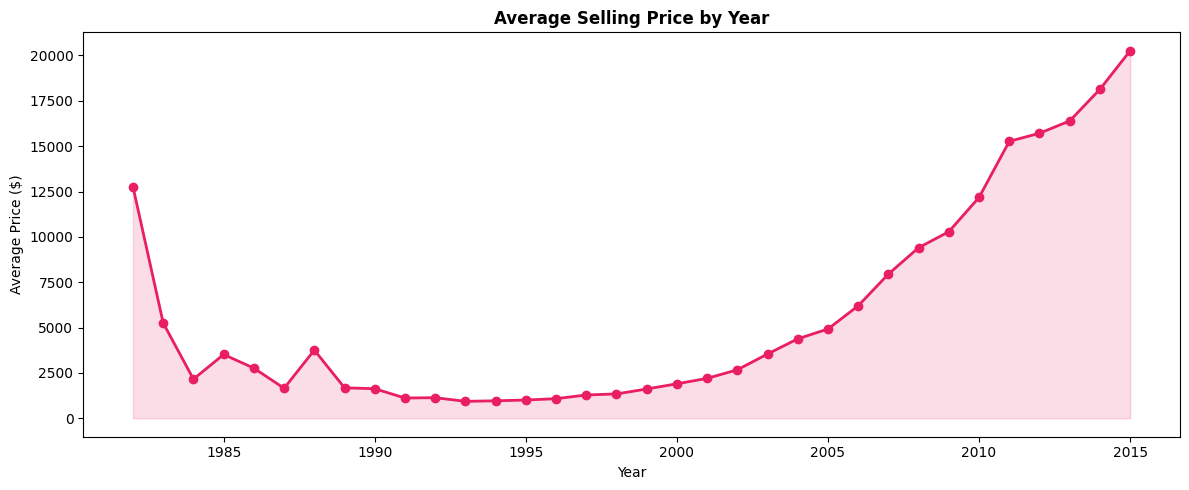

In [27]:
# Average Price by Year
year_avg = df.groupby('year')['sellingprice'].mean()
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(year_avg.index, year_avg.values, marker='o', color='#E91E63', linewidth=2)
ax.fill_between(year_avg.index, year_avg.values, alpha=0.15, color='#E91E63')
ax.set_title('Average Selling Price by Year', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Price ($)')
plt.tight_layout()
plt.show()

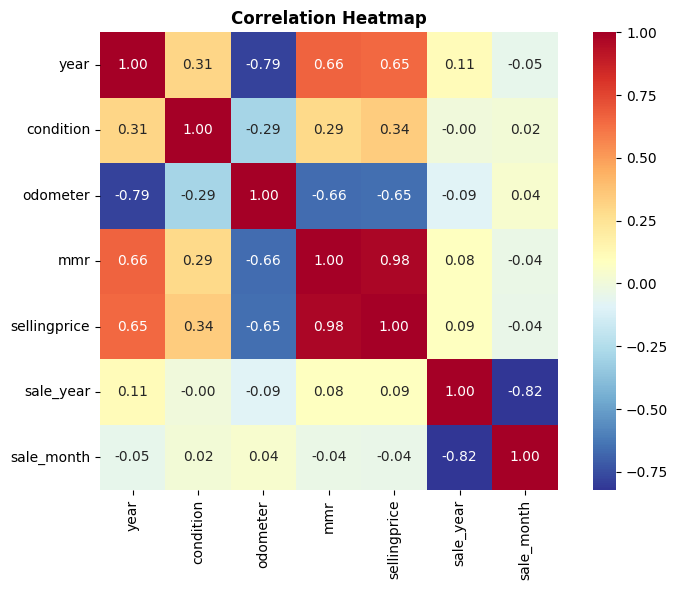

In [28]:
# Correlation Heatmap
num_cols = ['year', 'condition', 'odometer', 'mmr', 'sellingprice', 'sale_year', 'sale_month']
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='RdYlBu_r', square=True, ax=ax)
ax.set_title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [29]:
import datetime
current_year = datetime.datetime.now().year
df['vehicle_age'] = current_year - df['year']
df['mileage_per_year'] = df['odometer'] / df['vehicle_age'].replace(0, 1)

print("New features: vehicle_age, mileage_per_year")
df[['year', 'vehicle_age', 'odometer', 'mileage_per_year']].head()

New features: vehicle_age, mileage_per_year


,year,vehicle_age,odometer,mileage_per_year
0,2015,11,16639.0,1512.636364
1,2015,11,9393.0,853.909091
2,2014,12,1331.0,110.916667
3,2015,11,14282.0,1298.363636
5,2015,11,5554.0,504.909091


## 5. Model Building

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [37]:
# Encode categorical features
cat_cols = ['make', 'body', 'transmission', 'state', 'color']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

# Define features and target
features = ['year', 'condition', 'odometer', 'mmr', 'vehicle_age', 'mileage_per_year',
            'sale_year', 'sale_month',
            'make_enc', 'body_enc', 'transmission_enc', 'state_enc', 'color_enc']

X = df[features].copy()
y = df['sellingprice'].copy()

# Remove any rows with NaN or inf in features or target
X = X.replace([np.inf, -np.inf], np.nan)
valid = X.notnull().all(axis=1) & y.notnull()
X = X[valid]
y = y[valid]

print(f"Rows after removing NaN/inf: {len(X):,}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")

Rows after removing NaN/inf: 532,771
Train: 426,216  |  Test: 106,555


In [38]:
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Linear Regression Results:")
print(f"  R² Score : {r2:.4f}")
print(f"  MAE      : ${mae:,.2f}")
print(f"  RMSE     : ${rmse:,.2f}")

Linear Regression Results:
  R² Score : 0.9569
  MAE      : $1,030.01
  RMSE     : $1,593.86


## 6. Model Evaluation

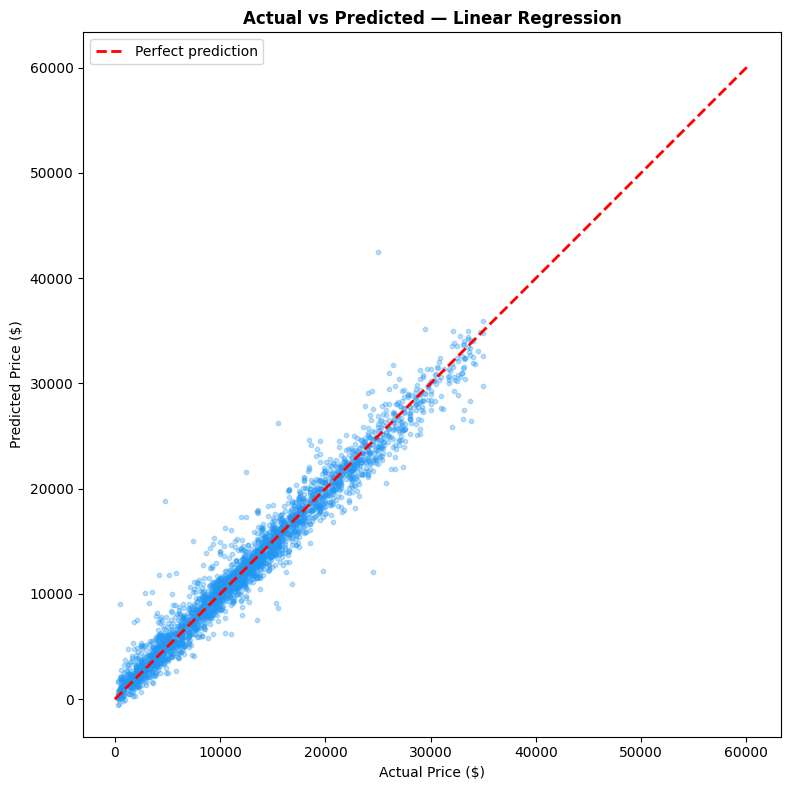

In [33]:
# Actual vs Predicted
fig, ax = plt.subplots(figsize=(8, 8))
idx = np.random.choice(len(y_test), 3000, replace=False)
ax.scatter(y_test.values[idx], y_pred[idx], alpha=0.3, s=10, color='#2196F3')
lim = max(y_test.max(), y_pred.max()) * 0.9
ax.plot([0, lim], [0, lim], 'r--', linewidth=2, label='Perfect prediction')
ax.set_title('Actual vs Predicted — Linear Regression', fontweight='bold')
ax.set_xlabel('Actual Price ($)')
ax.set_ylabel('Predicted Price ($)')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

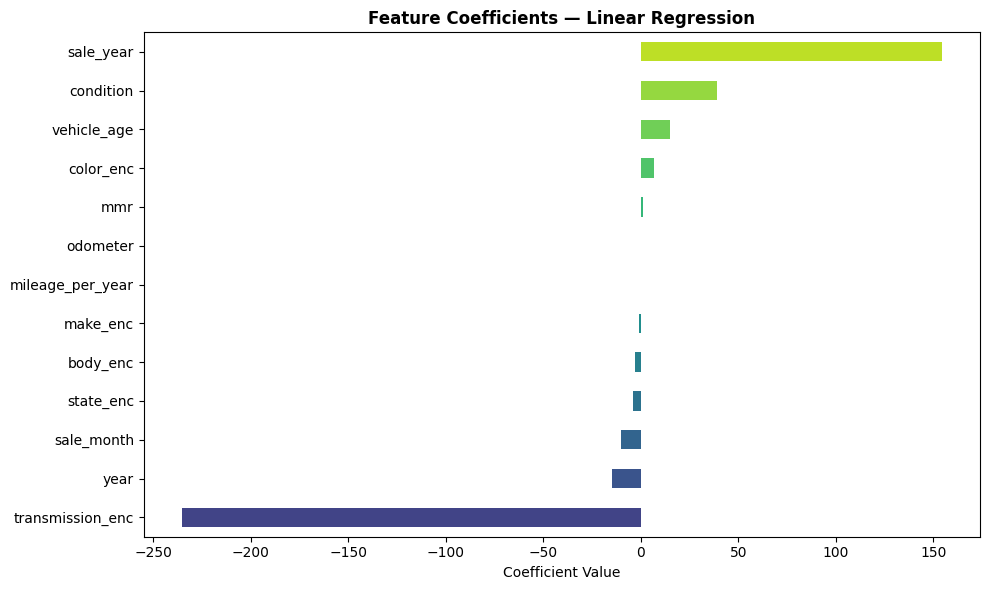

In [34]:
# Feature Coefficients (how much each feature influences the price)
coef = pd.Series(model.coef_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
coef.plot(kind='barh', color=plt.cm.viridis(np.linspace(0.2, 0.9, len(coef))), ax=ax)
ax.set_title('Feature Coefficients — Linear Regression', fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## 7. Save Model

In [35]:
import joblib
joblib.dump(model, 'vehicle_price_model.pkl')
joblib.dump(le_dict, 'label_encoders.pkl')
print("✅ Model (Linear Regression) and encoders saved.")

✅ Model (Linear Regression) and encoders saved.


## Summary

| Step | Done |
|------|------|
| Data Loading | ✅ |
| Data Cleaning | ✅ |
| EDA & Graphs | ✅ |
| Feature Engineering | ✅ |
| Model Training (Linear Regression) | ✅ |
| Evaluation | ✅ |
| Model Saved | ✅ |